# Importation du dataset

In [85]:
import os
os.getcwd
from datasets import load_dataset
from PIL import ImageDraw
from utils import calculate_iou, generate_fake_bounding_box

ModuleNotFoundError: No module named 'utils'

In [ ]:
dataset = load_dataset("HichTala/coco", streaming=True) # dota est utilisable à la place de coco

In [ ]:
iteration = iter(dataset['train'])

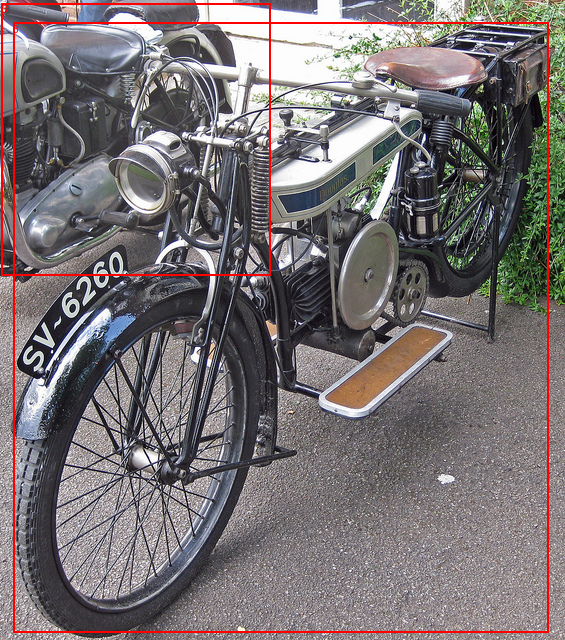

In [ ]:
data = next(iteration)
data['image']

# --- Dessin des bounding boxes ---

image_with_bboxes = data['image'].copy()
draw = ImageDraw.Draw(image_with_bboxes)

ground_truth_bboxes = data['objects']['bbox']
categories = data['objects']['category']

for i, box in enumerate(ground_truth_bboxes):
    x_min = box[0]
    y_min = box[1]
    x_max = box[0] + box[2]
    y_max = box[1] + box[3]
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)
    draw.text((x_min, y_min), str(categories[i]), fill="red")

image_with_bboxes

# Calcul de la mAP

In [ ]:
# PARAMÈTRES DE SIMULATION

NOMBRES_IMAGES_SIMULEES = 100
IOU_SEUIL = 0.5

In [ ]:
# --- SIMULATION DES PRÉDICTIONS ---

prediction_results = []  # Liste pour stocker les résultats des prédictions simulées
total_real_objects = 0 # Compteur pour le nombre total d'objets à detecter dans les images simulées

for gt_box in ground_truth_bboxes:
    total_real_objects += 1

    # Simulation du modèle de détection d'objets (on crée des prédictions aléatoires)
    prediction_box = generate_fake_bounding_box(gt_box)


    for gt_box in gt_boxes:
        # Générer une boîte englobante prédite aléatoire
        pred_box = generate_fake_bounding_box(gt_box)
        
        # Calculer l'IoU entre la boîte englobante prédite et la boîte englobante réelle
        iou = calculate_iou(gt_box, pred_box, image_width, image_height)
        
        # Déterminer si la prédiction est un vrai positif ou un faux positif
        if iou >= IOU_SEUIL:
            image_results.append(('TP', iou))
        else:
            image_results.append(('FP', iou))
    
    prediction_results.append(image_results)